# MIMIC-III Data Exploration
## Goal: Understand cleaned data before building RL pipeline

In [5]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load Core Tables

In [7]:
data_dir = Path('../artifacts/cleaned')

# Core patient and episode tables
patients = pd.read_parquet(data_dir / 'PATIENTS.parquet')
admissions = pd.read_parquet(data_dir / 'ADMISSIONS.parquet')
icustays = pd.read_parquet(data_dir / 'ICUSTAYS.parquet')

print(f"Patients: {len(patients):,}")
print(f"Admissions: {len(admissions):,}")
print(f"ICU Stays: {len(icustays):,}")

Patients: 100
Admissions: 129
ICU Stays: 136


## 2. Episode (ICU Stay) Statistics

ICU Length of Stay (days):
count    136.000000
mean       4.452457
std        6.196828
min        0.105900
25%        1.233525
50%        2.111450
75%        4.329050
max       35.406500
Name: los, dtype: float64


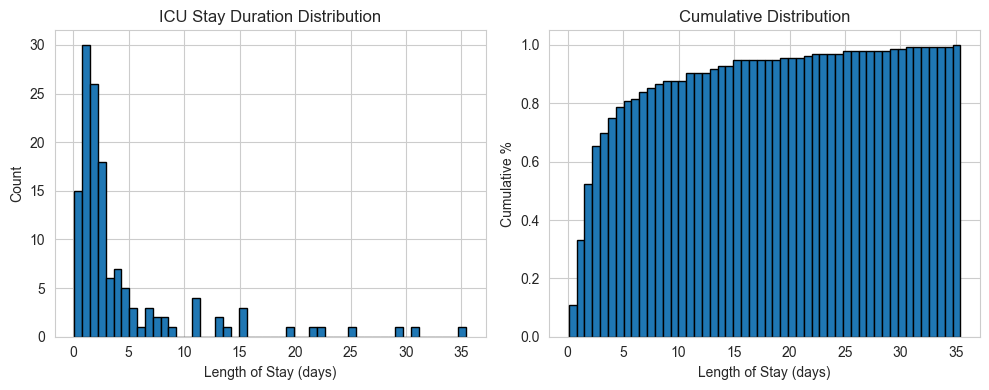

In [8]:
# ICU stay length distribution
print("ICU Length of Stay (days):")
print(icustays['los'].describe())

# Plot LOS distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
icustays['los'].hist(bins=50, edgecolor='black')
plt.xlabel('Length of Stay (days)')
plt.ylabel('Count')
plt.title('ICU Stay Duration Distribution')

plt.subplot(1, 2, 2)
icustays['los'].hist(bins=50, edgecolor='black', cumulative=True, density=True)
plt.xlabel('Length of Stay (days)')
plt.ylabel('Cumulative %')
plt.title('Cumulative Distribution')
plt.tight_layout()
plt.show()

## 3. Patient Demographics & Outcomes

In [9]:
# Merge patients with admissions to get outcomes
patient_outcomes = patients.merge(admissions, on='subject_id', how='inner')

print("\nGender distribution:")
print(patients['gender'].value_counts())

print("\nHospital mortality rate:")
mortality_rate = admissions['hospital_expire_flag'].mean()
print(f"{mortality_rate:.2%} ({admissions['hospital_expire_flag'].sum()} deaths)")

# Age calculation (accounting for de-identification)
patient_outcomes['admit_year'] = pd.to_datetime(patient_outcomes['admittime']).dt.year
patient_outcomes['birth_year'] = pd.to_datetime(patient_outcomes['dob']).dt.year
patient_outcomes['age_at_admit'] = patient_outcomes['admit_year'] - patient_outcomes['birth_year']

# Filter realistic ages (MIMIC has age > 89 set to 300)
realistic_ages = patient_outcomes[patient_outcomes['age_at_admit'] < 150]
print(f"\nAge distribution (n={len(realistic_ages)}):")
print(realistic_ages['age_at_admit'].describe())


Gender distribution:
gender
F    55
M    45
Name: count, dtype: int64

Hospital mortality rate:
31.01% (40 deaths)

Age distribution (n=120):
count    120.000000
mean      68.791667
std       16.021465
min       17.000000
25%       63.000000
50%       71.000000
75%       81.000000
max       89.000000
Name: age_at_admit, dtype: float64


## 4. Data Availability per Episode

In [10]:
# Load event tables
chartevents = pd.read_parquet(data_dir / 'CHARTEVENTS.parquet')
labevents = pd.read_parquet(data_dir / 'LABEVENTS.parquet')
inputevents_cv = pd.read_parquet(data_dir / 'INPUTEVENTS_CV.parquet')
inputevents_mv = pd.read_parquet(data_dir / 'INPUTEVENTS_MV.parquet')

print(f"Chart Events: {len(chartevents):,}")
print(f"Lab Events: {len(labevents):,}")
print(f"Input Events CV: {len(inputevents_cv):,}")
print(f"Input Events MV: {len(inputevents_mv):,}")

Chart Events: 758,355
Lab Events: 76,074
Input Events CV: 34,799
Input Events MV: 13,224


In [11]:
# Count events per ICU stay
icustay_ids = icustays['icustay_id'].unique()

chart_counts = chartevents.groupby('icustay_id').size()
lab_counts = labevents[labevents['hadm_id'].isin(icustays['hadm_id'])].groupby('hadm_id').size()
input_cv_counts = inputevents_cv.groupby('icustay_id').size()
input_mv_counts = inputevents_mv.groupby('icustay_id').size()

# Create data availability summary
availability = pd.DataFrame({
    'icustay_id': icustay_ids,
    'chart_events': chart_counts.reindex(icustay_ids, fill_value=0).values,
    'input_cv_events': input_cv_counts.reindex(icustay_ids, fill_value=0).values,
    'input_mv_events': input_mv_counts.reindex(icustay_ids, fill_value=0).values,
})

print("\nData availability per ICU stay:")
print(availability.describe())

# Episodes with complete data
complete_episodes = availability[
    (availability['chart_events'] > 0) & 
    ((availability['input_cv_events'] > 0) | (availability['input_mv_events'] > 0))
]
print(f"\nEpisodes with vitals + treatments: {len(complete_episodes)} ({len(complete_episodes)/len(icustays):.1%})")


Data availability per ICU stay:
          icustay_id  chart_events  input_cv_events  input_mv_events
count     136.000000    136.000000       136.000000       136.000000
mean   250980.470588   5575.544118       255.875000        97.235294
std     28455.125832  10256.444554       825.316213       324.263204
min    201006.000000      0.000000         0.000000         0.000000
25%    224359.250000   1120.500000         0.000000         0.000000
50%    250055.000000   2141.000000         0.000000         6.500000
75%    277279.250000   4545.750000       127.250000        42.500000
max    298685.000000  82169.000000      7653.000000      3094.000000

Episodes with vitals + treatments: 132 (97.1%)


## 5. Temporal Coverage

Admission date range:
  From: 2102-08-29 07:15:00
  To: 2202-10-03 01:45:00
  Span: 36558 days


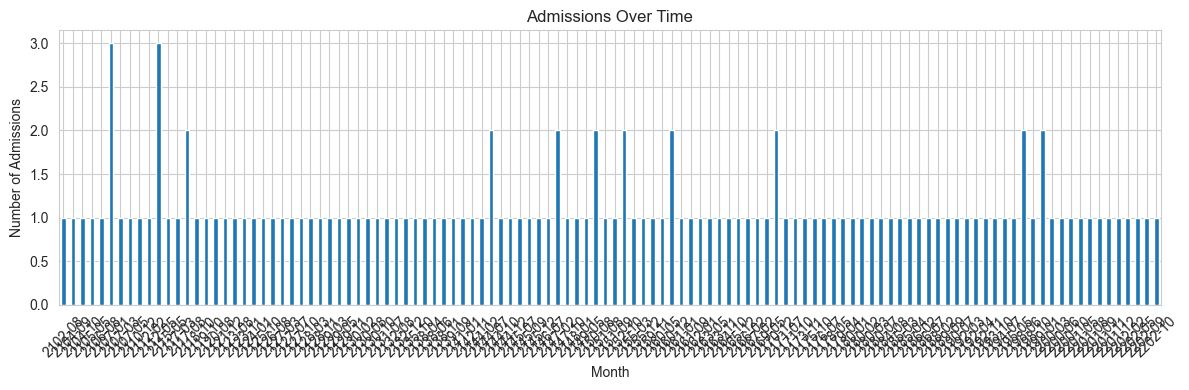

In [12]:
# Admission date range
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
print("Admission date range:")
print(f"  From: {admissions['admittime'].min()}")
print(f"  To: {admissions['admittime'].max()}")
print(f"  Span: {(admissions['admittime'].max() - admissions['admittime'].min()).days} days")

# ICU stay temporal coverage
icustays['intime'] = pd.to_datetime(icustays['intime'])
icustays['outtime'] = pd.to_datetime(icustays['outtime'])

# Plot admissions over time
plt.figure(figsize=(12, 4))
admissions.groupby(admissions['admittime'].dt.to_period('M')).size().plot(kind='bar')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.title('Admissions Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Key Insights for RL Pipeline

### Questions to answer:
1. How many episodes have sufficient data density for RL?
2. What's the typical observation frequency (for hourly aggregation)?
3. What's the class imbalance for mortality (reward signal)?
4. Are there temporal gaps that could break episode continuity?

In [13]:
# Sample one ICU stay for detailed temporal analysis
sample_icustay_id = complete_episodes.iloc[0]['icustay_id']
sample_stay = icustays[icustays['icustay_id'] == sample_icustay_id].iloc[0]

print(f"Sample ICU stay: {sample_icustay_id}")
print(f"  Duration: {sample_stay['los']:.1f} days")
print(f"  In: {sample_stay['intime']}")
print(f"  Out: {sample_stay['outtime']}")

# Get chart events for this stay
sample_charts = chartevents[chartevents['icustay_id'] == sample_icustay_id].copy()
sample_charts['charttime'] = pd.to_datetime(sample_charts['charttime'])
sample_charts = sample_charts.sort_values('charttime')

print(f"  Chart events: {len(sample_charts)}")

# Time between observations
time_diffs = sample_charts['charttime'].diff().dt.total_seconds() / 3600  # hours
print(f"\nTime between chart events (hours):")
print(time_diffs.describe())

Sample ICU stay: 206504
  Duration: 1.6 days
  In: 2164-10-23 21:10:15
  Out: 2164-10-25 12:21:07
  Chart events: 920

Time between chart events (hours):
count    919.000000
mean       0.038448
std        0.257617
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        4.000000
Name: charttime, dtype: float64


## Next Steps

Based on this exploration:

1. **Define state space**: Which chart items (vitals) and lab items to include
2. **Hourly aggregation**: Design aggregation strategy for irregular observations
3. **Action space**: Identify key medications from INPUTEVENTS to discretize
4. **Reward function**: Implement survival-based or clinical improvement reward
5. **Episode filtering**: Set minimum data density requirements
6. **Train/test split**: Stratify by patient to avoid leakage